# TP1 — Réseaux de véhicules : modélisation par graphes et diffusion d'information 

### Module ISAC — réseaux véhiculaires coopératifs

**Comment travailler ce TP**
- Exécuter les cellules **dans l'ordre** (Maj+Entrée).
- Compléter les zones `TODO`.
- Les blocs **Question** attendent une réponse écrite et argumentée.
- Le TP se déroule en deux parties, **A puis B**, qui s'enchaînent : les fonctions construites en Partie A sont directement réutilisées en Partie B.

# Partie A — Modéliser le réseau 

Avant d'étudier *comment* l'information circule, on apprend à représenter un réseau de véhicules par un **graphe** et à mesurer sa structure. On termine par un réseau **qui bouge**, modélisé comme une suite de graphes — le support de toute la suite du TP.

In [31]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import time
from IPython import display

tailleMap = 200   # taille du cote de la carte (la zone est tailleMap x tailleMap) 

## 1. Un graphe de proximite

On place `N` vehicules sur une carte carree de cote `tailleMap`. Deux vehicules peuvent
communiquer (il y a une **arete** entre eux) si et seulement si ils sont a portee radio,
c'est-a-dire a une distance inferieure ou egale a `R`.

In [32]:
def graphe_proximite(positions, R):
    """Construit le graphe de proximite d'un ensemble de vehicules.

    Parametres :
        positions : tableau numpy de forme (N, 2). Chaque ligne i contient
                    les coordonnees (x, y) du vehicule i sur la carte.
        R         : portee radio (en metres). Deux vehicules sont relies
                    par une arete si leur distance est inferieure ou egale a R.
    Retourne :
        G : graphe networkx dont les noeuds sont les vehicules (0..N-1),
            chacun portant son attribut 'pos' (sa position).
    """
    G = nx.Graph()
    N = len(positions)
    for i in range(N):
        G.add_node(i, pos=positions[i])
    for i in range(N):
        for j in range(i + 1, N):
            distance = np.linalg.norm(positions[i] - positions[j])
            relie = distance <= R
            if relie:
                G.add_edge(i, j)
    return G

rng = np.random.default_rng()            # tirages aleatoires : les resultats varient a chaque execution
N = 15
positions = rng.random((N, 2)) * tailleMap
R = 80.0                                  # portee radio (essayer aussi 50, puis 150)
G = graphe_proximite(positions, R)
print("Nombre d'aretes :", G.number_of_edges())

Nombre d'aretes : 40


### Visualiser le reseau

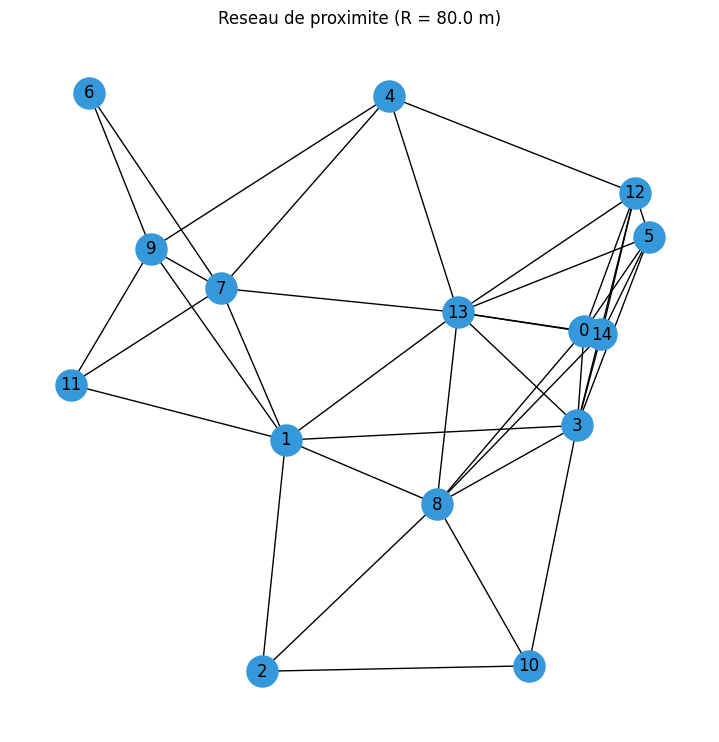

In [33]:
pos_dict = {i: positions[i] for i in range(N)} # { voiture0 : (x,y) }
plt.figure(figsize=(7, 7))
nx.draw(G, pos=pos_dict, with_labels=True, node_color='#3498db', node_size=500)
plt.title(f"Reseau de proximite (R = {R} m)")
plt.show()

## 2. Mesurer la structure

Trois indicateurs simples decrivent deja beaucoup le reseau :
- le **degre** d'un vehicule : son nombre de voisins ;
- le nombre de **composantes connexes** : le nombre d'ilots de vehicules qui ne peuvent pas se joindre ;
- le **diametre** : le plus long des plus courts chemins (en nombre de sauts) dans le plus gros ilot.

In [34]:
degres = dict(G.degree())
print("Degre moyen :", round(np.mean(list(degres.values())), 2))

composantes = list(nx.connected_components(G))
print("Nombre de composantes connexes :", len(composantes))

plus_grosse = max(composantes, key=len)
sousG = G.subgraph(plus_grosse)
if len(plus_grosse) > 1:
    print("Diametre de la plus grosse composante :", nx.diameter(sousG), "sauts")
else:
    print("La plus grosse composante est un seul noeud (reseau tres fragmente).")

Degre moyen : 5.33
Nombre de composantes connexes : 1
Diametre de la plus grosse composante : 4 sauts


## 3. Question critique — l'effet de la portee R

On fait varier `R` et on regarde la taille de la plus grosse composante connexe
(en % du reseau). Executer la cellule, puis repondre en dessous.

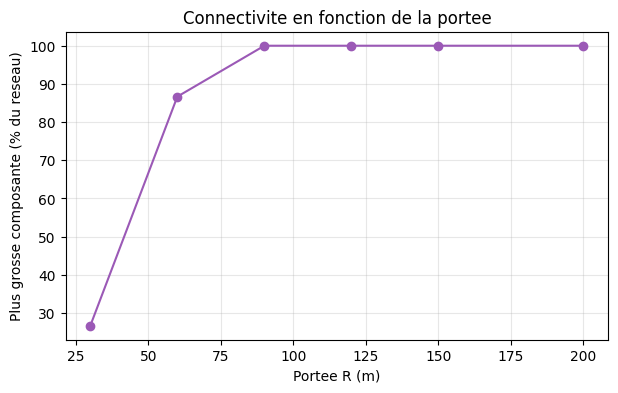

In [9]:
valeurs_R = [30, 60, 90, 120, 150, 200]
taille_max = []
for r in valeurs_R:
    g = graphe_proximite(positions, r)
    plus_grosse = max(nx.connected_components(g), key=len)
    taille_max.append(len(plus_grosse) / N * 100)

plt.figure(figsize=(7, 4))
plt.plot(valeurs_R, taille_max, 'o-', color='#9b59b6')
plt.xlabel("Portee R (m)"); plt.ylabel("Plus grosse composante (% du reseau)")
plt.title("Connectivite en fonction de la portee"); plt.grid(alpha=0.3)
plt.show()

**Reponse attendue.** Quand `R` augmente, chaque vehicule a plus de voisins, donc les ilots
fusionnent : la plus grosse composante grandit jusqu'a englober tout le reseau (100 %).
En dessous d'un certain seuil de portee, le reseau reste **fragmente** : une information ne peut
pas atteindre tout le monde, quel que soit le protocole de diffusion. Les valeurs exactes
varient d'une execution a l'autre (positions aleatoires), mais l'allure de la courbe reste
la meme : une transition assez brutale autour d'une portee critique.

## 4. Un reseau qui bouge : le graphe dynamique

Les vehicules se deplacent. On ne decrit donc pas un seul graphe, mais une **suite de graphes**
(un par instant), appeles *snapshots*. A chaque pas de temps, on recalcule les aretes selon
les nouvelles positions (les vehicules rebondissent sur les bords de la carte).

In [35]:
def generer_snapshots(N, R, steps, vmax, tailleMap):
    """Genere la suite des graphes (snapshots) d'un reseau de vehicules mobiles.

    Parametres :
        N         : nombre de vehicules.
        R         : portee radio (metres) utilisee pour construire chaque graphe.
        steps     : nombre de pas de temps simules (un graphe par pas).
        vmax      : vitesse maximale des vehicules (amplitude du deplacement par pas).
        tailleMap : taille du cote de la carte carree (la zone est tailleMap x tailleMap).
    Retourne :
        snaps : liste de `steps` graphes networkx, un par instant.
    Remarque : les positions et vitesses initiales sont tirees au hasard a chaque
    execution (pas de graine fixe), les resultats varient donc d'un lancement a l'autre.
    """
    rng = np.random.default_rng()
    pos = rng.random((N, 2)) * tailleMap
    vel = (rng.random((N, 2)) - 0.5) * vmax
    snaps = []
    for _ in range(steps):
        pos += vel
        hors = (pos < 0) | (pos > tailleMap)   # rebond sur les bords
        vel[hors] *= -1
        pos = np.clip(pos, 0, tailleMap)
        snaps.append(graphe_proximite(pos.copy(), R))
    return snaps

snapshots = generer_snapshots(N=15, R=80, steps=60, vmax=8, tailleMap=tailleMap)
print("Nombre de snapshots :", len(snapshots))

Nombre de snapshots : 60


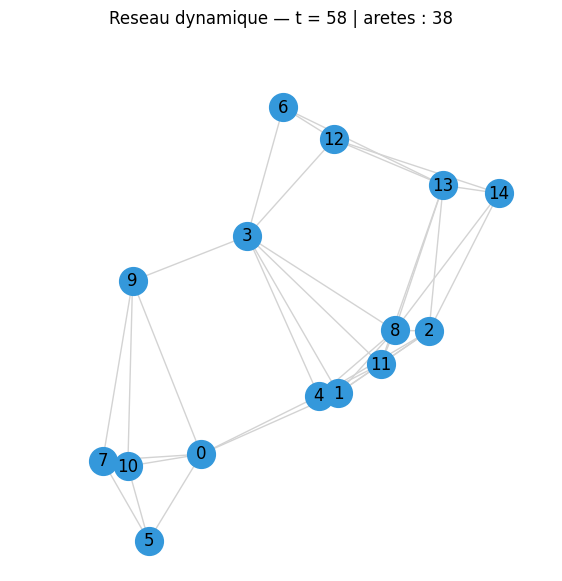

In [36]:
# Animation de la mobilite
fig, ax = plt.subplots(figsize=(7, 7))
for t in range(0, len(snapshots), 2):
    ax.clear()
    G = snapshots[t]
    pos_dict = nx.get_node_attributes(G, 'pos')
    nx.draw(G, pos=pos_dict, with_labels=True, node_color='#3498db',
            node_size=400, edge_color='lightgray', ax=ax)
    ax.set_xlim(-10, tailleMap + 10); ax.set_ylim(-10, tailleMap + 10)
    ax.set_title(f"Reseau dynamique — t = {t} | aretes : {G.number_of_edges()}")
    display.display(fig); display.clear_output(wait=True)
    time.sleep(0.1)
display.display(fig); plt.close(fig)

# Partie B — Faire circuler une information : flooding vs gossip

*Transition.* Nous savons maintenant représenter un réseau dynamique. Mais un réseau n'a d'intérêt que s'il fait **circuler** de l'information. Un véhicule (la *source*) détient une information : comment la propager à tout le réseau construit en Partie A ? On compare deux stratégies opposées — le **flooding** et le **gossip** — et on mesure le compromis **couverture / coût**.

On réutilise directement les outils de la Partie A (`graphe_proximite`, `generer_snapshots`) ; il suffit de construire le réseau de travail.

In [37]:
# --- On reprend l'outillage de la Partie A (deja defini ci-dessus) ---
# Pour bien observer la diffusion, on construit un reseau un peu plus grand.
tailleMap = 300                 # zone un peu plus large que pour la prise en main
N, steps = 20, 80
snapshots = generer_snapshots(N=N, R=80, steps=steps, vmax=8, tailleMap=tailleMap)
source = 10                      # le vehicule qui detient l'information au depart
print("Reseau de diffusion :", N, "vehicules,", steps, "pas de temps")

Reseau de diffusion : 20 vehicules, 80 pas de temps


## 1. Le flooding : emettre a tous les voisins

A chaque pas de temps, **tout** vehicule informe transmet l'information a **tous** ses voisins.
C'est rapide et fiable, mais cela genere beaucoup de transmissions. On compte une transmission
(`tx`) a chaque fois qu'un vehicule informe parle a un voisin.

In [38]:
def flooding(snapshots, source=0):
    """Simule la diffusion par flooding sur une suite de snapshots.

    Parametres :
        snapshots : liste de graphes networkx (un par pas de temps).
        source    : identifiant du vehicule qui connait l'information au depart.
    Retourne :
        history  : liste, pour chaque pas, de l'ensemble des vehicules informes.
        tx_count : liste du nombre de transmissions effectuees a chaque pas.
    """
    informed = {source}
    history = [informed.copy()]
    tx_count = [0]
    for G in snapshots[1:]:
        tx = 0
        nouveaux = set()
        for node in informed:
            for voisin in G.neighbors(node):
                if voisin not in informed:
                    nouveaux.add(voisin)
                tx += 1            # une transmission par voisin contacte
        informed |= nouveaux
        history.append(informed.copy())
        tx_count.append(tx)
    return history, tx_count

## 2. Le gossip : emettre a un seul voisin choisi au hasard

A chaque pas, un vehicule informe ne contacte **qu'un seul voisin tire au hasard**
(on pourra utiliser `np.random.choice`). Beaucoup moins de transmissions, mais la
diffusion est plus lente et son deroulement depend du hasard.

In [39]:
def gossip(snapshots, source=0):
    """Simule la diffusion par gossip sur une suite de snapshots.

    Parametres :
        snapshots : liste de graphes networkx (un par pas de temps).
        source    : identifiant du vehicule qui connait l'information au depart.
    Retourne :
        history  : liste, pour chaque pas, de l'ensemble des vehicules informes.
        tx_count : liste du nombre de transmissions effectuees a chaque pas.
    """
    informed = {source}
    history = [informed.copy()]
    tx_count = [0]
    for G in snapshots[1:]:
        tx = 0
        nouveaux = set()
        for node in informed:
            voisins = list(G.neighbors(node))
            if voisins:
                target = np.random.choice(voisins)
                if target not in informed:
                    nouveaux.add(target)
                tx += 1
        informed |= nouveaux
        history.append(informed.copy())
        tx_count.append(tx)
    return history, tx_count

## 3. Lancer les deux et mesurer

La **couverture** mesure la proportion du reseau informee a un instant donne :
$$\text{Couverture (\%)} = \frac{\text{Nombre de vehicules informes}}{\text{Nombre total de vehicules}} \times 100$$

In [40]:
hist_flood, tx_flood = flooding(snapshots, source)
hist_gossip, tx_gossip = gossip(snapshots, source)

def courbe_couverture(history):
    """Convertit un historique de diffusion en courbe de couverture.

    Parametres :
        history : liste, pour chaque pas de temps, de l'ensemble des vehicules informes.
    Retourne :
        valeurs : liste de la couverture (%) a chaque pas de temps.
    """
    valeurs = []
    for infos in history:
        couverture = len(infos) / N * 100
        valeurs.append(couverture)
    return valeurs

cov_flood = courbe_couverture(hist_flood)
cov_gossip = courbe_couverture(hist_gossip)
print("Couverture finale — flooding :", round(cov_flood[-1]), "%  |  gossip :", round(cov_gossip[-1]), "%")

Couverture finale — flooding : 95 %  |  gossip : 95 %


### Visualiser la propagation (rouge = source, orange = informe, bleu = ignorant)

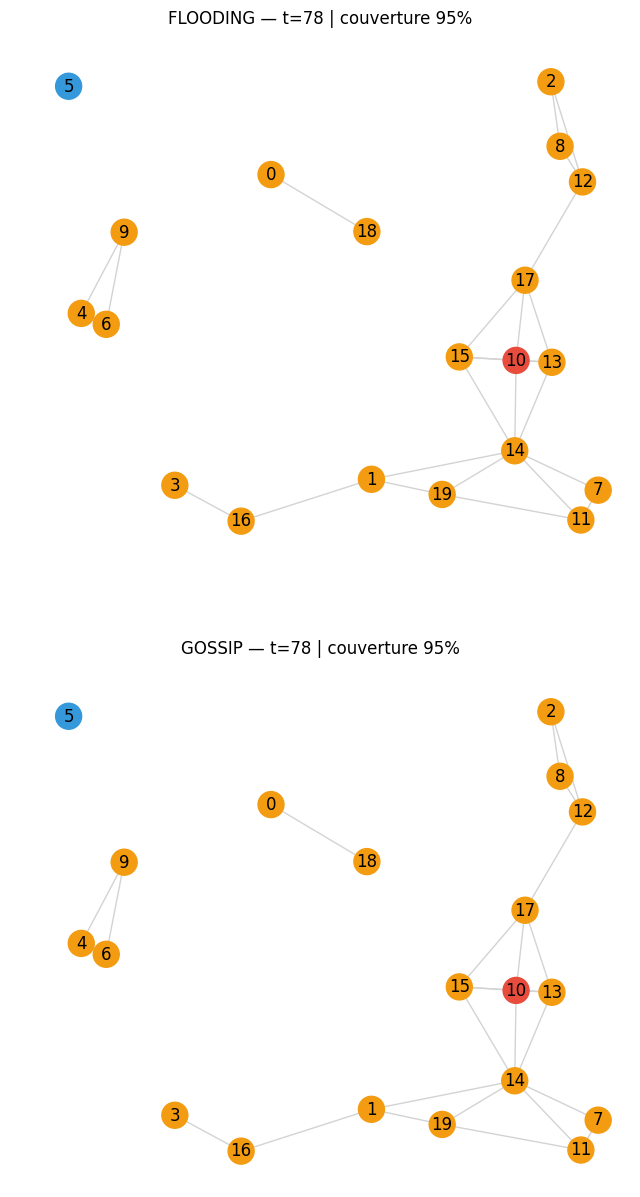

In [42]:
fig, axes = plt.subplots(2, 1, figsize=(8, 15))
for t in range(0, steps, 2):
    G = snapshots[t]; pos_dict = nx.get_node_attributes(G, 'pos')
    for ax, hist, nom in [(axes[0], hist_flood, "FLOODING"), (axes[1], hist_gossip, "GOSSIP")]:
        ax.clear()
        couleurs = []
        for node in G.nodes():
            if node == source: couleurs.append('#e74c3c')
            elif node in hist[t]: couleurs.append('#f39c12')
            else: couleurs.append('#3498db')
        nx.draw(G, pos=pos_dict, with_labels=True, node_color=couleurs,
                node_size=350, edge_color='lightgray', ax=ax)
        cov = len(hist[t]) / N * 100
        ax.set_title(f"{nom} — t={t} | couverture {cov:.0f}%")
        ax.set_xlim(-10, tailleMap + 10); ax.set_ylim(-10, tailleMap + 10)
    display.display(fig); display.clear_output(wait=True)
    time.sleep(0.1)
display.display(fig); plt.close(fig)

### Le compromis : couverture vs cout

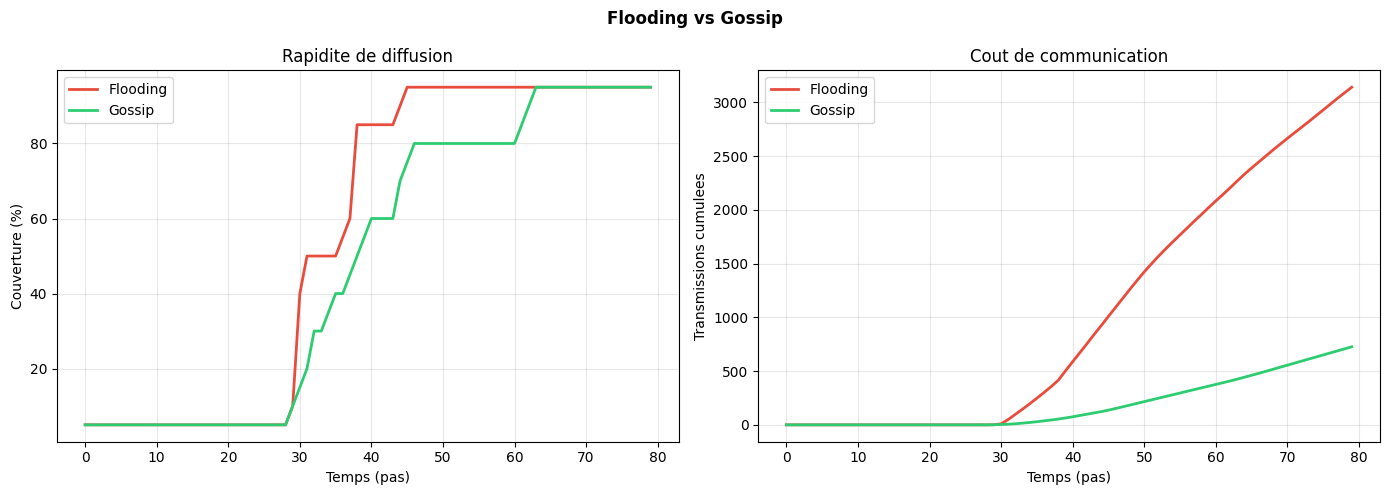

Cout total — flooding : 3141 transmissions  |  gossip : 726


In [43]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(cov_flood, label='Flooding', color='#e74c3c', linewidth=2)
axes[0].plot(cov_gossip, label='Gossip', color='#2ecc71', linewidth=2)
axes[0].set_xlabel('Temps (pas)'); axes[0].set_ylabel('Couverture (%)')
axes[0].set_title('Rapidite de diffusion'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(np.cumsum(tx_flood), label='Flooding', color='#e74c3c', linewidth=2)
axes[1].plot(np.cumsum(tx_gossip), label='Gossip', color='#2ecc71', linewidth=2)
axes[1].set_xlabel('Temps (pas)'); axes[1].set_ylabel('Transmissions cumulees')
axes[1].set_title('Cout de communication'); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle('Flooding vs Gossip', fontweight='bold'); plt.tight_layout(); plt.show()

print(f"Cout total — flooding : {sum(tx_flood)} transmissions  |  gossip : {sum(tx_gossip)}")

## 4. Questions critiques

**Q1.** Pourquoi le gossip est-il plus lent que le flooding, mais beaucoup moins couteux ?

**Q2.** Dans un reseau vehiculaire reel ou la bande passante est limitee, lequel choisir ? Le choix depend-il de l'urgence de l'information ?

**Q3 (ouverture).** Le flooding fait beaucoup de transmissions inutiles (vers des vehicules deja informes). Comment pourrait-on les eviter ?

---
## Conclusion du TP1

**Partie A — modéliser**
- Un réseau de véhicules se modélise par un **graphe de proximité** (arête si distance ≤ portée).
- La **portée** conditionne la connectivité : trop faible, le réseau est fragmenté.
- Un réseau qui bouge est une **suite de graphes** ; les liens sont **intermittents**.

**Partie B — diffuser**
- **Flooding** : rapide, fiable, coûteux (beaucoup de redondance).
- **Gossip** : lent, économe, dépendant du hasard.
- Il existe un **compromis couverture / coût** : aucune stratégie n'est parfaite dans l'absolu.

**Suite — TP2.** Et si toutes les informations n'avaient pas la même valeur ? On introduira la **perception** de l'environnement (le « S » de l'ISAC), puis la **sélection** de l'information utile sous contraintes de ressources.